In [1]:
import math
import json
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys
from typing import List, Dict
# --- Local Modules ---
# Dynamically add `src/` to sys.path (go up two levels)
notebook_dir = Path.cwd()
sys.path.append(str(notebook_dir.parents[1] / "src"))

from nbutils.compile_plot import compile_zne_subplots
from nbutils.zne_plot import plot_zne_result
from nbutils.summarize import summarize_zne_results
from nbutils.export_raw_data_wrapped import export_raw_data_wrapped
from nbutils.riczne import RichardsonZne
from nbutils.lsf_zne_hill import *
from nbutils.data_loader import load_all_experiments

from nbutils.lsf_zne import *

#### Plot markup settting

In [2]:
plt.rcParams.update({
    "font.family": "serif",
    #"font.serif": "Computer Modern Roman",
    "font.size": 10,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "legend.frameon": False,
})

---

### Load experimental data

In [3]:
# ==========================================
# Recursive experiment loader
# ==========================================

def load_all_experiments(data_root):
    """
    Recursively load all experiments under data_root and
    populate a master data_records dictionary.

    Parameters
    ----------
    data_root : str or Path
        Root directory containing experiment folders (e.g. data/)

    Returns
    -------
    data_records : dict
        Master experiment registry
    """
    data_root = Path(data_root)
    data_records = {}

    # Iterate over subdirectories like c0, c0.01, ...
    for exp_dir in sorted(p for p in data_root.iterdir() if p.is_dir()):
        experiment_id = exp_dir.name

        json_files = sorted(exp_dir.rglob("iter_*.json"))
        if not json_files:
            continue  # skip empty folders

        # --------------------------
        # Load and group raw data
        # --------------------------
        raw_groups = {}
        exact_solution = None

        for jf in json_files:
            with open(jf, "r") as f:
                data = json.load(f)

            t_max = data["config"]["ansatz"]["ugate"]["time"]["max"]
            cost = data["output"]["optimized_minimum_cost"][0]

            if exact_solution is None:
                exact_solution = data["output"].get("exact_sol", None)

            raw_groups.setdefault(t_max, []).append(cost)

        # --------------------------
        # Processed arrays
        # --------------------------
        t_vals = np.array(sorted(raw_groups.keys()))
        vqe_means = np.array([np.mean(raw_groups[t]) for t in t_vals])
        vqe_stds = np.array([np.std(raw_groups[t]) for t in t_vals])

        # --------------------------
        # Register experiment
        # --------------------------
        data_records[experiment_id] = {
            "meta": {
                "experiment_id": experiment_id,
                "data_path": str(exp_dir),
                "num_json_files": len(json_files),
                "noise_level": float(experiment_id.replace("c", "")) if experiment_id.startswith("c") else None,
            },

            "raw": {
                "json_files": [str(f) for f in json_files],
                "grouped_costs": raw_groups,
            },

            "processed": {
                "t_max": t_vals,
                "vqe_means": vqe_means,
                "vqe_stds": vqe_stds,
                "exact_solution": exact_solution,
            },

        }

    return data_records

In [4]:
data_records = load_all_experiments("data")

In [5]:
# ==========================================
# DATA EXTRACTION
# ==========================================
data_dir = Path("data/c0")
json_files = sorted(data_dir.rglob("iter_*.json"))

raw_groups, exact_sol = {}, None
for f in json_files:
    with open(f, "r") as file:
        data = json.load(file)
        big_t = data["config"]["ansatz"]["ugate"]["time"]["max"]
        cost = data["output"]["optimized_minimum_cost"][0]
        #if exact_sol is None: exact_sol = data["output"]["exact_sol"]
        if big_t not in raw_groups: raw_groups[big_t] = []
        raw_groups[big_t].append(cost)

EXPERIMENTAL_PROCESSED_DATA = [[(np.mean(raw_groups[t]), np.std(raw_groups[t])), t] for t in sorted(raw_groups.keys())]
print(f"Len: {len(EXPERIMENTAL_PROCESSED_DATA)}")
print(f"Extracted data for {EXPERIMENTAL_PROCESSED_DATA} noise levels.")

Len: 51
Extracted data for [[(3.0000000817631687, 6.991934657836011e-08), 0], [(1.512344102998239, 0.013932395296170701), 1], [(0.34048750489580726, 0.035478751604426574), 2], [(-1.015718826414441, 0.0345301431008247), 3], [(-2.4914599115717384, 0.08496204398301681), 4], [(-3.295158795505818, 0.2343733313117736), 5], [(-4.062004110615584, 0.15865549389626196), 6], [(-4.710940886686118, 0.21010772943622058), 7], [(-4.848972203941356, 0.19079480233245977), 8], [(-5.124314668335285, 0.1621580343826099), 9], [(-5.36806750137307, 0.19087855942686316), 10], [(-5.530711658622038, 0.16442349747081578), 11], [(-5.68977426806609, 0.16536366548814804), 12], [(-5.724989888801153, 0.1599278825799889), 13], [(-5.797664146300366, 0.12925006513377796), 14], [(-5.8500918167345475, 0.11648195027346925), 15], [(-5.817524418404128, 0.1475214842575809), 16], [(-5.904683436616966, 0.07204586425527805), 17], [(-5.9298316312568415, 0.07567479045998024), 18], [(-5.910673807120366, 0.10301714506773366), 19], [(

In [6]:
#LSF_WINDOWS = [(10, 40), (10, 50), (10, 60), (10, 70), (10, 80), (10, 90), (10, 100)]
LSF_WINDOWS = [(0, 30), (0,40), (0, 50)]
EXACT_SOLUTION = -6.026674183332271
print("EXACT_SOLUTION =", EXACT_SOLUTION)

EXACT_SOLUTION = -6.026674183332271


In [7]:
# Extracting components
vqe_means_c0 = data_records["c0"]["processed"]["vqe_means"]
vqe_stds_c0 = data_records["c0"]["processed"]["vqe_stds"]
noise_levels_c0 = data_records["c0"]["processed"]["t_max"]

print(f"Loaded {len(noise_levels_c0)} data points.")
print("EXACT_SOLUTION =", EXACT_SOLUTION)

Loaded 51 data points.
EXACT_SOLUTION = -6.026674183332271


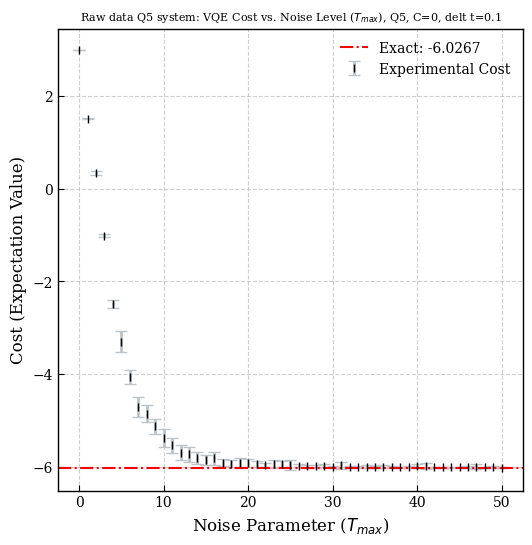

In [8]:
# Create a single clear plot
plt.figure(figsize=(6, 6))
plt.errorbar(noise_levels_c0, vqe_means_c0, yerr=vqe_stds_c0, fmt='|', color='black', 
             ecolor='#bdc3c7', elinewidth=2, capsize=4, markersize=6, 
             label='Experimental Cost')

plt.axhline(y=EXACT_SOLUTION, color='red', linestyle='-.', label=f'Exact: {EXACT_SOLUTION:.4f}')
# Aesthetic improvements
plt.title("Raw data Q5 system: VQE Cost vs. Noise Level ($T_{max}$), Q5, C=0, delt t=0.1", fontsize=8)
plt.xlabel("Noise Parameter ($T_{max}$)", fontsize=12)
plt.ylabel("Cost (Expectation Value)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Save the plot (if in a script) or show (if in a notebook)
#plt.savefig('raw_data_trend.png')
plt.show()

---

### $n$ from noise-free $C=0$ in $T_{max}$ range [0, 30]

In [9]:
# Noiseless guesses
ZNE_GUESS_NOISELESS = -5.0
A0_GUESS_NOISELESS = 10.0
T0_GUESS_NOISELESS = 8.0

In [10]:
"""
Extract experimental data.

Definitions:
    t        → T_max (noise scaling parameter)
    y        → measured energy
    sigma    → standard deviation (optional)
"""
mask = 31
t = noise_levels_c0[:mask]          # T_max
y = vqe_means_c0[:mask]
std_wt = 0.01
sigma = std_wt + vqe_stds_c0[:mask]

"""
Fixed Hill exponents to test.
"""

n_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# Initial guess for fitted parameters:
#   p0[0] = ZNE → zero-noise extrapolated energy
#   p0[1] = A0  → amplitude = f(0) - ZNE (must be positive)
#   p0[2] = T0  → characteristic noise scale
#   p0 = [ZNE_guess, A0_guess, T0_guess]

# Guesses for noise-free data hill fitting
ZNE_GUESS_NOISELESS = -5.0
A0_GUESS_NOISELESS = 10.0

T0_GUESS_NOISELESS = 8.0
p0 = [ZNE_GUESS_NOISELESS, A0_GUESS_NOISELESS, T0_GUESS_NOISELESS]

bounds = (
    [-10.0, 0.0, 0],
    [-1.0, 20.0, 50.0],
)

fit_results = {}
for n in n_values:

    result_fit_hill_noiseless_across_n = fit_hill_noiseless(
        t=t,
        y=y,
        sigma=sigma,
        n=n,
        p0=p0,
        bounds=bounds,
        xtol=1e-10,
        ftol=1e-10,
        gtol=1e-10,
        max_nfev=5000,
    )

    ZNE, A0, T0 = result_fit_hill_noiseless_across_n["output"]["popt"]
    pcov = result_fit_hill_noiseless_across_n["output"]["pcov"]

    y_fit = hill(t=t, ZNE=ZNE, A=A0, T0=T0, n=n)
    residuals = y - y_fit

    LS = np.sum((residuals / sigma) ** 2)
    dof = len(y) - 3
    LS_red = LS / dof

    # Store results in dictionary
    fit_results[n] = {
        "initial_guess": {"ZNE0": p0[0], "A0_0": p0[1], "T0_0": p0[2]},
        "params": {"ZNE": ZNE, "A0": A0, "T0": T0},
        "LS": LS_red,
    }
# --- Print Summary Table ---
print(f"T_max range [0, 30]: {t}\n\n")
print(
    f"{'n':>2} | "
    f"{'ZNE_init':>9} | {'A0_init':>9} | {'T0_init':>8} || "
    f"{'ZNE_fit':>9} | {'A0_fit':>9} | {'T0_fit':>8} | "
    f"{'LS':>8}"
)
print("-" * 96)

for n, res in fit_results.items():
    ig = res["initial_guess"]
    p  = res["params"]

    print(
        f"{n:2d} | "
        f"{ig['ZNE0']:9.3f} | "
        f"{ig['A0_0']:9.3f} | "
        f"{ig['T0_0']:8.2f} || "
        f"{p['ZNE']:9.4f} | "
        f"{p['A0']:9.4f} | "
        f"{p['T0']:8.2f} | "
        f"{res['LS']:8.3f}"
    )

T_max range [0, 30]: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30]


 n |  ZNE_init |   A0_init |  T0_init ||   ZNE_fit |    A0_fit |   T0_fit |       LS
------------------------------------------------------------------------------------------------
 1 |    -5.000 |    10.000 |     8.00 ||   -7.8104 |   10.8439 |     5.07 |   33.802
 2 |    -5.000 |    10.000 |     8.00 ||   -6.0875 |    9.0206 |     3.04 |   25.351
 3 |    -5.000 |    10.000 |     8.00 ||   -5.9365 |    8.7690 |     2.98 |   88.591
 4 |    -5.000 |    10.000 |     8.00 ||   -5.9073 |    8.6807 |     3.03 |  138.008
 5 |    -5.000 |    10.000 |     8.00 ||   -5.8952 |    8.6358 |     3.07 |  172.480
 6 |    -5.000 |    10.000 |     8.00 ||   -5.8876 |    8.6075 |     3.09 |  197.901
 7 |    -5.000 |    10.000 |     8.00 ||   -5.8811 |    8.5875 |     3.10 |  217.025
 8 |    -5.000 |    10.000 |     8.00 ||   -5.8746 |    8.5723 |     3.10 |  231.458
 9 |    -5.000 |   

In [11]:
BEST_n_FROM_C0  = 2
######################################################################
BEST_T0_FROM_C0 = fit_results[BEST_n_FROM_C0]["params"]["T0"]
BEST_A0_FROM_C0 = fit_results[BEST_n_FROM_C0]["params"]["A0"]
ZNE_c0_best = fit_results[BEST_n_FROM_C0]["params"]["ZNE"]
E_mix   = 0.0   # Tr(H_Ising) = 0

lsf_record_c0 = {
    "model": "ZNE + A/(1+(t/T0)^n)",
    "lsf": fit_results,
    "bests": {
        "n": BEST_n_FROM_C0,
        "A": BEST_A0_FROM_C0,
        "T0": BEST_T0_FROM_C0,
        "ZNE": ZNE_c0_best,
    }
}
print(f"Best n = {BEST_n_FROM_C0}")
print(f"BEST_T0_FROM_C0 = {BEST_T0_FROM_C0}")
print(f"BEST_A0_FROM_C0 = {BEST_A0_FROM_C0}")
print(f"ZNE_c0_best = {ZNE_c0_best}")

Best n = 2
BEST_T0_FROM_C0 = 3.042397899782802
BEST_A0_FROM_C0 = 9.02055870884778
ZNE_c0_best = -6.087516684866581


---

##  Noisy LSF with $C$=0.05

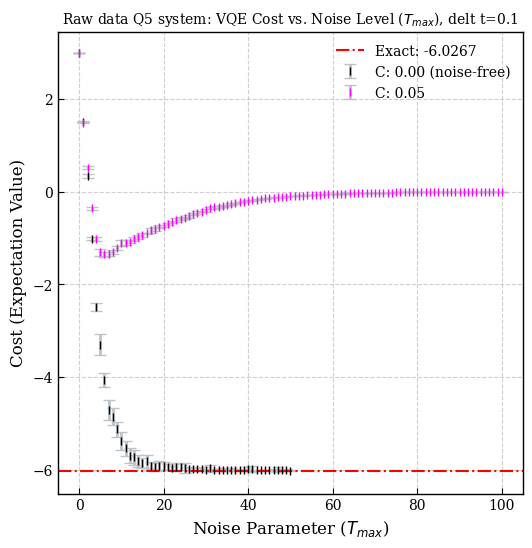

In [12]:
TARGET_C = "c0.05"
C_VAL_str = "C: 0.05"
vqe_means = data_records[TARGET_C]["processed"]["vqe_means"]
vqe_stds = data_records[TARGET_C]["processed"]["vqe_stds"]
noise_levels = data_records[TARGET_C]["processed"]["t_max"]
# Create a single clear plot
plt.figure(figsize=(6, 6))
plt.errorbar(noise_levels_c0, vqe_means_c0, yerr=vqe_stds_c0, fmt='|', color='black', 
             ecolor='#bdc3c7', elinewidth=2, capsize=4, markersize=6, 
             label='C: 0.00 (noise-free)')
plt.errorbar(noise_levels, vqe_means, yerr=vqe_stds, fmt='|', color='magenta', 
             ecolor='#bdc3c7', elinewidth=2, capsize=4, markersize=6, 
             label=C_VAL_str)
plt.axhline(y=EXACT_SOLUTION, color='red', linestyle='-.', label=f'Exact: {EXACT_SOLUTION:.4f}')
# Aesthetic improvements
plt.title("Raw data Q5 system: VQE Cost vs. Noise Level ($T_{max}$), delt t=0.1", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)", fontsize=12)
plt.ylabel("Cost (Expectation Value)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Save the plot (if in a script) or show (if in a notebook)
# plt.savefig('raw_data_trend.png')
plt.show()

#### $\gamma$ from large $T_{max} = [50, 100]$

In [13]:
# =========================
# Data selection (large-t window)
# =========================
mask = 51
rec = data_records[TARGET_C]

t = rec["processed"]["t_max"][-mask:]
y = rec["processed"]["vqe_means"][-mask:]
sigma = rec["processed"]["vqe_stds"][-mask:]

# =========================
# Initial guesses and bounds
# Model: f(t) = B * exp(-gamma * t)
# Parameter order: [gamma, B]
# =========================
B_guess = BEST_A0_FROM_C0 + ZNE_c0_best
p0 = [
    0.05,      # gamma: slow decay at large-t
    B_guess,      # B: first point in large-t window
]

bounds = (
    [1e-6, -np.inf],   # gamma > 0, B free
    [1.0,   np.inf],   # gamma not too large (stiff), B free
)

# =========================
# Call the fitter
# =========================
result_fit_gamma_largeT = fit_gamma_largeT(
    t=t,
    y=y,
    sigma=sigma,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
    verbose=2,
)

# =========================
# Extract results
# =========================
popt = result_fit_gamma_largeT["output"]["popt"]
pcov = result_fit_gamma_largeT["output"]["pcov"]

gamma_fit, B_fit = popt

GAMMA_FROM_LARGE_T = gamma_fit
B_FROM_LARGE_T     = B_fit

# =========================
# Clean summary table
# =========================
print(f"\nLarge-T Exponential Fit: f(t) = B · exp(−γ t) with T = {t}\n")
print(f"{'param':>6} | {'initial':>12} | {'fitted':>12}")
print("-" * 36)
print(f"{'gamma':>6} | {p0[0]:12.4e} | {gamma_fit:12.4e}")
print(f"{'B':>6} | {p0[1]:12.4e} | {B_fit:12.4e}")

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         4.3069e+05                                    4.88e+07    
       1              2         1.8739e+04      4.12e+05       2.93e+00       3.79e+04    
       2              3         1.8959e+03      1.68e+04       9.12e-01       1.95e+04    
       3              4         1.1444e+03      7.51e+02       8.59e-01       2.61e+04    
       4              5         1.9990e+02      9.45e+02       1.02e+00       1.21e+04    
       5              6         3.4192e+01      1.66e+02       8.46e-01       5.40e+03    
       6              7         1.0101e+01      2.41e+01       3.62e-01       6.76e+02    
       7              8         9.7500e+00      3.51e-01       5.09e-02       1.29e+01    
       8              9         9.7499e+00      9.36e-05       3.35e-04       1.45e-03    
       9             10         9.7499e+00      2.39e-11       8.19e-07       2.78e-04    

#### $(ZNE, A, T_0)$ from small $T_{max}=[0, 5]$

In [14]:
# =========================
# Data selection (large-t window)
# =========================
mask = 6
rec = data_records[TARGET_C]

t = rec["processed"]["t_max"][:mask]
y = rec["processed"]["vqe_means"][:mask]
sigma = rec["processed"]["vqe_stds"][:mask]

# Initial guess and bounds
p0 = [
    ZNE_GUESS_NOISELESS, # ZNE from noise less c=0
    A0_GUESS_NOISELESS,     # A from noiseless c=0
    T0_GUESS_NOISELESS,     # T0 from noiseless c=0
]

bounds = (
    [-10.0,   0.0,  0], # lower [ ZNE, A, T0 ]
    [ 0., 200.0, 10],   # upper [ ZNE, A, T0 ]
)

result_fit_in_smallT = fit_smallT_ZNE(
    t=t,
    y=y,
    sigma=sigma,
    n=BEST_n_FROM_C0,          # fixed exponent BEST_n=2
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
    verbose=2,
)

# =====================================================
# Clean parameter summary (initial vs fitted)
# =====================================================

popt = result_fit_in_smallT["output"]["popt"]
pcov = result_fit_in_smallT["output"]["pcov"]

ZNE_fit, A_fit, T0_fit = popt

ZNE_FROM_NOISY_SMALL_T = ZNE_fit
A_FROM_NOISY_SMALL_T   = A_fit
T0_FROM_NOISY_SMALL_T  = T0_fit

print(f"\nSmall-T Hill Fit:  f(t) = ZNE + A / (1 + (t/T0)^n) with n=2, T = {t}\n")
print(f"{'param':>6} | {'initial':>12} | {'fitted':>12}")
print("-" * 36)
print(f"{'ZNE':>6} | {p0[0]:12.4f} | {ZNE_fit:12.4f}")
print(f"{'A':>6} | {p0[1]:12.4f} | {A_fit:12.4f}")
print(f"{'T0':>6} | {p0[2]:12.4f} | {T0_fit:12.4f}")


   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         6.3580e+14                                    6.36e+15    
       1              2         8.8000e+12      6.27e+14       3.44e+00       6.60e+14    
       2              3         2.6849e+09      8.80e+12       1.62e+00       1.13e+13    
       3              4         5.2774e+03      2.68e+09       4.42e-01       3.58e+09    
       4              5         4.9065e+03      3.71e+02       1.05e-01       4.54e+03    
       5              6         1.1144e+03      3.79e+03       4.83e+00       7.98e+03    
       6              7         2.5349e+02      8.61e+02       1.04e+00       5.10e+04    
       7              8         1.3137e+02      1.22e+02       5.50e-01       3.49e+02    
       8              9         1.2168e+02      9.69e+00       1.88e-01       4.43e+06    
       9             10         1.2166e+02      1.98e-02       9.51e-04       2.73e+01    

---

In [15]:
print("All fitted parameters:")
print("****************************")
print(f"GAMMA_FROM_LARGE_T = {GAMMA_FROM_LARGE_T}")
print(f"B_FROM_LARGE_T = {B_FROM_LARGE_T}")
print(f"ZNE_FROM_NOISY_SMALL_T = {ZNE_FROM_NOISY_SMALL_T}")
print(f"A_FROM_NOISY_SMALL_T = {A_FROM_NOISY_SMALL_T}")
print(f"T0_FROM_NOISY_SMALL_T = {T0_FROM_NOISY_SMALL_T}")
print("****************************")   
print("End of fitted parameters.")

All fitted parameters:
****************************
GAMMA_FROM_LARGE_T = 0.07352969483847696
B_FROM_LARGE_T = -4.055041546764959
ZNE_FROM_NOISY_SMALL_T = -1.0903804072926624
A_FROM_NOISY_SMALL_T = 4.090380463637056
T0_FROM_NOISY_SMALL_T = 1.315557382428651
****************************
End of fitted parameters.


---

In [16]:
F_NOISY_EQ = rf"$f(t) = e^{{-\gamma t^q}} [\mathrm{{ZNE}} + \frac{{A}}{{1 + (t/T_0)^n}}]$" + f"\n$n={BEST_n_FROM_C0}, q=0.7$"

#### Whole system fitting in $T_{max}=[0, 50]$


Fit Results (n=2):
 Param |      Initial |       Fitted |        Error | Rel. Error
---------------------------------------------------------------------------
 gamma |   7.3530e-02 |   2.3621e-01 |   1.6427e-03 | 6.95e-03
   ZNE |  -1.0904e+00 |  -4.4289e+00 |   7.7131e-02 | 1.74e-02
     A |   4.0904e+00 |   7.4289e+00 |   7.7131e-02 | 1.04e-02
    T0 |   1.3156e+00 |   2.5301e+00 |   2.5093e-02 | 9.92e-03


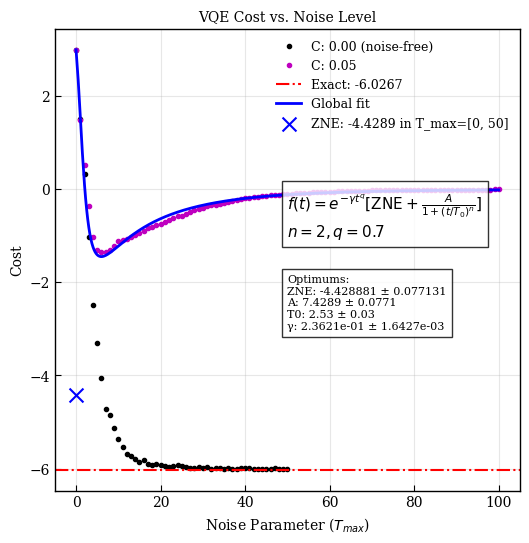

In [17]:
# --- Configuration & Parameters ---
mask_idx = 51
n_exponent = BEST_n_FROM_C0
q=0.7
# --- Data Extraction ---
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][:mask_idx]
# Initial guesses and bounds [gamma, ZNE, A, T0]
p0 = [
    GAMMA_FROM_LARGE_T,
    ZNE_FROM_NOISY_SMALL_T,
    A_FROM_NOISY_SMALL_T,
    T0_FROM_NOISY_SMALL_T
]
bounds = (
    [1e-6, -10.0, 0.0, 0],
    [1, 0., 200.0, 10]
)


# --- Execution: Global Fit ---
result_global = fit_f_noisy(
    t=t_data, y=y_data, sigma=sigma_data, n=n_exponent, q=q,
    p0=p0, bounds=bounds, method="trf", ftol=1e-12, xtol=1e-12, gtol=1e-12
)

popt = result_global["output"]["popt"]
pcov = result_global["output"]["pcov"]

# Calculate least square errors (standard deviation) from the covariance matrix
perr = np.sqrt(np.diag(pcov))

gamma_fit, ZNE_fit, A_fit, T0_fit = popt
gamma_err, ZNE_err, A_err, T0_err = perr

# --- Print Summary ---
print(f"\nFit Results (n={n_exponent}):")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)
params = ['gamma', 'ZNE', 'A', 'T0']
for i, name in enumerate(params):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

# --- Visualization ---
def f_noisy_model(t, g, z, a, t0, n=n_exponent):
    return np.exp(-g * (t**q)) * (z + a / (1.0 + (t / t0) ** n))

t_grid = np.linspace(min(noise_levels), max(noise_levels), 400)
y_fit = f_noisy_model(t_grid, *popt)

plt.figure(figsize=(6, 6))

# Data points
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', label="C: 0.00 (noise-free)")
plt.plot(noise_levels, vqe_means, 'm.', label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit results
plt.plot(t_grid, y_fit, color="blue", lw=2, label="Global fit")
plt.scatter(0, ZNE_fit, color="blue", marker="x", s=100, zorder=5, label=f"ZNE: {ZNE_fit:.4f} in T_max=[0, {mask_idx-1}]")

# Annotation & Style
# Including the error +/- in the optimum string
optimum_val_str = (
    f"Optimums:\n"
    f"ZNE: {ZNE_fit:.6f} ± {ZNE_err:.6f}\n"
    f"A: {A_fit:.4f} ± {A_err:.4f}\n"
    f"T0: {T0_fit:.2f} ± {T0_err:.2f}\n"
    f"γ: {gamma_fit:.4e} ± {gamma_err:.4e}"
)

eq_text = (F_NOISY_EQ)
plt.text(0.5, 0.55, eq_text, transform=plt.gca().transAxes, fontsize=11, bbox=dict(facecolor='white', alpha=0.8))
plt.text(0.5, 0.35, optimum_val_str, transform=plt.gca().transAxes, fontsize=8, bbox=dict(facecolor='white', alpha=0.8))

plt.title("VQE Cost vs. Noise Level", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)
plt.show()

#### Whole system fitting in $T_{max}=[0, 100]$


Fit Results (n=2):
 Param |      Initial |       Fitted |        Error | Rel. Error
---------------------------------------------------------------------------
 gamma |   7.3530e-02 |   3.0431e-01 |   6.9997e-04 | 2.30e-03
   ZNE |  -1.0904e+00 |  -8.6820e+00 |   1.0266e-01 | 1.18e-02
     A |   4.0904e+00 |   1.1682e+01 |   1.0266e-01 | 8.79e-03
    T0 |   1.3156e+00 |   3.8313e+00 |   3.2924e-02 | 8.59e-03


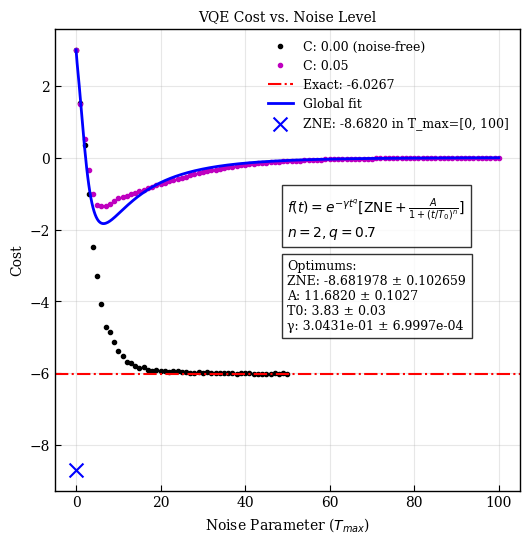

In [18]:
# --- Configuration & Parameters ---
mask_idx = 101
n_exponent = BEST_n_FROM_C0
# --- Data Extraction ---
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][:mask_idx]

# Initial guesses and bounds [gamma, ZNE, A, T0]
p0 = [
    GAMMA_FROM_LARGE_T,
    ZNE_FROM_NOISY_SMALL_T,
    A_FROM_NOISY_SMALL_T,
    T0_FROM_NOISY_SMALL_T
]
bounds = (
    [1e-6, -10.0, 0.0, 0],
    [1, 0., 200.0, 10]
)



# --- Execution: Global Fit ---
result_global = fit_f_noisy(
    t=t_data, y=y_data, sigma=sigma_data, n=n_exponent, q=q,
    p0=p0, bounds=bounds, method="trf", ftol=1e-12, xtol=1e-12, gtol=1e-12
)

popt = result_global["output"]["popt"]
pcov = result_global["output"]["pcov"]

# Calculate least square errors (standard deviation) from the covariance matrix
perr = np.sqrt(np.diag(pcov))

gamma_fit, ZNE_fit, A_fit, T0_fit = popt
gamma_err, ZNE_err, A_err, T0_err = perr

# --- Print Summary ---
print(f"\nFit Results (n={n_exponent}):")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)
params = ['gamma', 'ZNE', 'A', 'T0']
for i, name in enumerate(params):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

# --- Visualization ---
def f_noisy_model(t, g, z, a, t0, n=n_exponent):
    return np.exp(-g * (t**q)) * (z + a / (1.0 + (t / t0) ** n))

t_grid = np.linspace(min(noise_levels), max(noise_levels), 400)
y_fit = f_noisy_model(t_grid, *popt)

plt.figure(figsize=(6, 6))

# Data points
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', label="C: 0.00 (noise-free)")
plt.plot(noise_levels, vqe_means, 'm.', label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit results
plt.plot(t_grid, y_fit, color="blue", lw=2, label="Global fit")
plt.scatter(0, ZNE_fit, color="blue", marker="x", s=100, zorder=5, label=f"ZNE: {ZNE_fit:.4f} in T_max=[0, {mask_idx-1}]")

# Annotation & Style
# Including the error +/- in the optimum string
optimum_val_str = (
    f"Optimums:\n"
    f"ZNE: {ZNE_fit:.6f} ± {ZNE_err:.6f}\n"
    f"A: {A_fit:.4f} ± {A_err:.4f}\n"
    f"T0: {T0_fit:.2f} ± {T0_err:.2f}\n"
    f"γ: {gamma_fit:.4e} ± {gamma_err:.4e}"
)

eq_text = (F_NOISY_EQ)
plt.text(0.5, 0.55, eq_text, transform=plt.gca().transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
plt.text(0.5, 0.35, optimum_val_str, transform=plt.gca().transAxes, fontsize=9, bbox=dict(facecolor='white', alpha=0.8))

plt.title("VQE Cost vs. Noise Level", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)
plt.show()

---

#### Optimizing $q$ test

In [19]:
F_NOISY_EQ = rf"$f(t) = e^{{-\gamma t^q}} [\mathrm{{ZNE}} + \frac{{A}}{{1 + (t/T_0)^n}}]$" + f"\n$n={BEST_n_FROM_C0}$"


Fit Results (n=2), T_max=[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50]
 Param |      Initial |       Fitted |        Error | Rel. Error
---------------------------------------------------------------------------
 gamma |   3.0431e-01 |   2.3621e-01 |   1.6442e-02 | 6.96e-02
   ZNE |  -8.6820e+00 |  -4.4289e+00 |   2.4631e-01 | 5.56e-02
     A |   1.1682e+01 |   7.4289e+00 |   2.4631e-01 | 3.32e-02
    T0 |   3.8313e+00 |   2.5301e+00 |   9.1322e-02 | 3.61e-02
     q |   8.0000e-01 |   7.0000e-01 |   1.4142e-02 | 2.02e-02


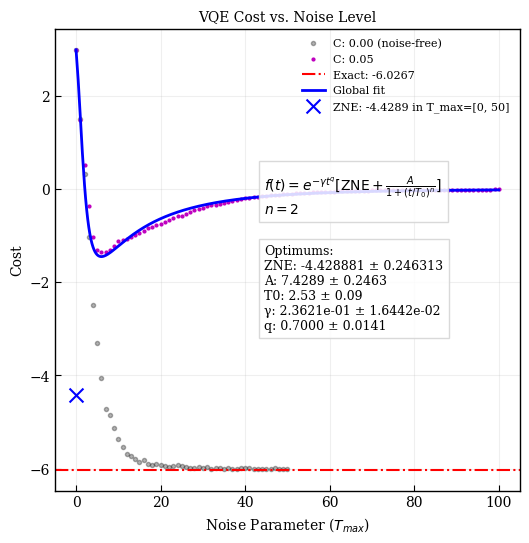

In [20]:
# --- Configuration & Parameters ---
mask_idx = 51
n_exponent = BEST_n_FROM_C0

# Initial guesses and bounds [gamma, ZNE, A, T0, q]
# p0 uses your carefully crafted variables with q initialized at 1.0
p0 = [
    gamma_fit, ZNE_fit, A_fit, T0_fit,
    0.8
]

bounds = (
    [1e-6, -10.0, 0.0, 0, 0.7], # Lower
    [1.0, 0.0, 200.0, 10, 1.3]   # Upper (constrained q to +10%)
)

# --- Data Extraction ---
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][:mask_idx]

# --- Execution: Global Fit ---
# Note: Using your updated function name fit_fq_noisy
result_global = fit_fq_noisy(
    t=t_data, y=y_data, sigma=sigma_data, n=n_exponent,
    p0=p0, bounds=bounds, method="trf", ftol=1e-12, xtol=1e-12, gtol=1e-12
)

popt = result_global["output"]["popt"]
pcov = result_global["output"]["pcov"]

# Calculate least square errors from covariance matrix
perr = np.sqrt(np.diag(pcov))

# Unpacking results
gamma_fit, ZNE_fit, A_fit, T0_fit, q_fit = popt
gamma_err, ZNE_err, A_err, T0_err, q_err = perr

# --- Print Summary ---
print(f"\nFit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)
params_names = ['gamma', 'ZNE', 'A', 'T0', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

# --- Visualization ---
# Cleaned up model to work correctly with *popt unpacking
def f_noisy_model(t, g, z, a, t0, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (z + a / (1.0 + (t / t0) ** n))

t_grid = np.linspace(min(noise_levels), max(noise_levels), 400)
# This now correctly passes (t_grid, gamma, ZNE, A, T0, q_fit)
y_fit = f_noisy_model(t_grid, *popt)

plt.figure(figsize=(6, 6))

# Data points
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=0.3, label="C: 0.00 (noise-free)")
plt.plot(noise_levels, vqe_means, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit results
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"Global fit")
plt.scatter(0, ZNE_fit, color="blue", marker="x", s=100, zorder=5, label=f"ZNE: {ZNE_fit:.4f} in T_max=[0, {mask_idx-1}]")

# Annotation & Style
optimum_val_str = (
    f"Optimums:\n"
    f"ZNE: {ZNE_fit:.6f} ± {ZNE_err:.6f}\n"
    f"A: {A_fit:.4f} ± {A_err:.4f}\n"
    f"T0: {T0_fit:.2f} ± {T0_err:.2f}\n"
    f"γ: {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q: {q_fit:.4f} ± {q_err:.4f}"
)

# Placed boxes in a clear area (middle-right)
plt.text(0.45, 0.60, F_NOISY_EQ, transform=plt.gca().transAxes, fontsize=10, 
         bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray'))
plt.text(0.45, 0.35, optimum_val_str, transform=plt.gca().transAxes, fontsize=9, 
         bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray'))

plt.title("VQE Cost vs. Noise Level", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()

---

```Could you find the optimal value of q by the following method.
First, picking up the noiseless value of (ZNE, A, T_0) from the noiseless data.
That is,
just use the optimal value for the noiseless fitting.

Then, by using  the optimal value  of (ZNE, A, T_0) as "constant",
Just optimize only p and γ.```

In [21]:
# From noieles data
print(f"Best n = {BEST_n_FROM_C0}")
print(f"BEST_T0_FROM_C0 = {BEST_T0_FROM_C0}")
print(f"BEST_A0_FROM_C0 = {BEST_A0_FROM_C0}")
print(f"ZNE_c0_best = {ZNE_c0_best}")

Best n = 2
BEST_T0_FROM_C0 = 3.042397899782802
BEST_A0_FROM_C0 = 9.02055870884778
ZNE_c0_best = -6.087516684866581



Gamma–q Fit Results (n=2), T_max=[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50]
 Param |      Initial |       Fitted |        Error | Rel. Error
---------------------------------------------------------------------------
 gamma |   7.3530e-02 |   3.2431e-01 |   3.5586e-03 | 1.10e-02
     q |   8.0000e-01 |   6.4042e-01 |   3.1323e-03 | 4.89e-03


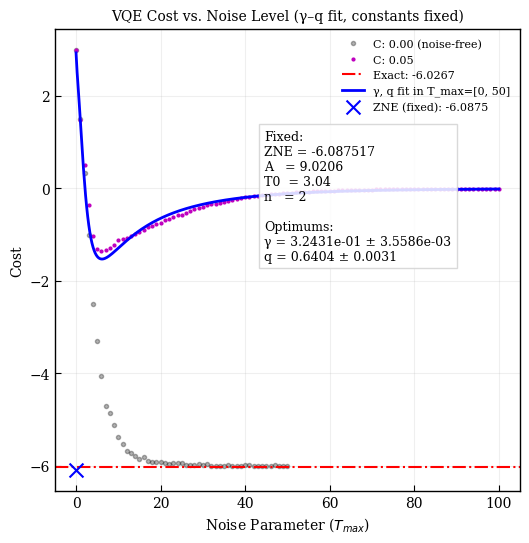

In [22]:
# --- Configuration & Parameters ---
mask_idx = 51

# Fixed constants (naming preserved)
n_exponent = BEST_n_FROM_C0

# Initial guesses and bounds [gamma, q]
p0 = [
    GAMMA_FROM_LARGE_T,  # reuse previous gamma estimate
    0.8
]

bounds = (
    [1e-6, 0.6],   # Lower bounds [gamma, q]
    [1.0,  1.3],   # Upper bounds
)

# --- Data Extraction ---
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][:mask_idx]

# --- Execution: Gamma–q Fit (constants fixed) ---
result_gq = fit_fq_noisy_gamma_q_only(
    t=t_data,
    y=y_data,
    sigma=sigma_data,
    ZNE=ZNE_c0_best,
    A=BEST_A0_FROM_C0,
    T0=BEST_T0_FROM_C0,
    n=n_exponent,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

popt = result_gq["output"]["popt"]
pcov = result_gq["output"]["pcov"]

# Errors
perr = np.sqrt(np.diag(pcov))

# Unpack
gamma_fit, q_fit = popt
gamma_err, q_err = perr

# --- Print Summary ---
print(f"\nGamma–q Fit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)

params_names = ['gamma', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

# --- Visualization ---
def f_noisy_model_fixed(t, g, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (
        ZNE_c0_best + BEST_A0_FROM_C0 / (1.0 + (t / BEST_T0_FROM_C0) ** n)
    )

t_grid = np.linspace(min(noise_levels), max(noise_levels), 400)
y_fit = f_noisy_model_fixed(t_grid, gamma_fit, q_fit)

plt.figure(figsize=(6, 6))

# Data
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=0.3, label="C: 0.00 (noise-free)")
plt.plot(noise_levels, vqe_means, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"γ, q fit in T_max=[0, {mask_idx-1}]")
plt.scatter(
    0, ZNE_c0_best,
    color="blue", marker="x", s=100, zorder=5,
    label=f"ZNE (fixed): {ZNE_c0_best:.4f}"
)

# Annotation
optimum_val_str = (
    f"Fixed:\n"
    f"ZNE = {ZNE_c0_best:.6f}\n"
    f"A   = {BEST_A0_FROM_C0:.4f}\n"
    f"T0  = {BEST_T0_FROM_C0:.2f}\n"
    f"n   = {n_exponent}\n\n"
    f"Optimums:\n"
    f"γ = {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q = {q_fit:.4f} ± {q_err:.4f}"
)

plt.text(
    0.45, 0.50, optimum_val_str,
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray')
)

plt.title("VQE Cost vs. Noise Level (γ–q fit, constants fixed)", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()



Gamma–q Fit Results (n=2), T_max=[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100]
 Param |      Initial |       Fitted |        Error | Rel. Error
---------------------------------------------------------------------------
 gamma |   7.3530e-02 |   2.1579e-01 |   1.8554e-03 | 8.60e-03
     q |   8.0000e-01 |   7.6582e-01 |   2.0384e-03 | 2.66e-03


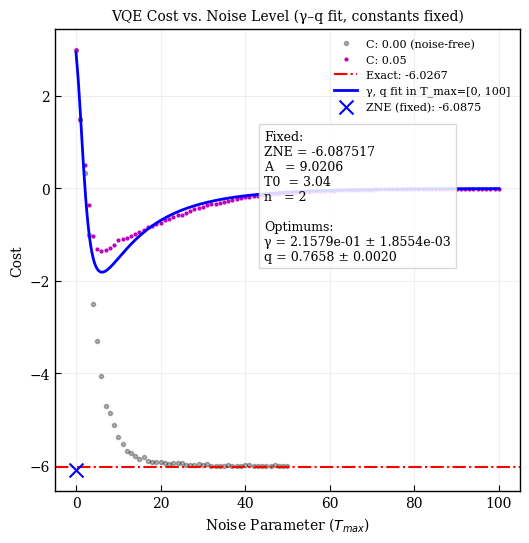

In [23]:
# --- Configuration & Parameters ---
mask_idx = 101

# Initial guesses and bounds [gamma, q]
p0 = [
    GAMMA_FROM_LARGE_T,  # reuse previous gamma estimate
    0.8
]

bounds = (
    [1e-6, 0.6],   # Lower bounds [gamma, q]
    [1.0,  1.3],   # Upper bounds
)

# --- Data Extraction ---
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][:mask_idx]

# --- Execution: Gamma–q Fit (constants fixed) ---
result_gq = fit_fq_noisy_gamma_q_only(
    t=t_data,
    y=y_data,
    sigma=sigma_data,
    ZNE=ZNE_c0_best,
    A=BEST_A0_FROM_C0,
    T0=BEST_T0_FROM_C0,
    n=n_exponent,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

popt = result_gq["output"]["popt"]
pcov = result_gq["output"]["pcov"]

# Errors
perr = np.sqrt(np.diag(pcov))

# Unpack
gamma_fit, q_fit = popt
gamma_err, q_err = perr

# --- Print Summary ---
print(f"\nGamma–q Fit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)

params_names = ['gamma', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

# --- Visualization ---
def f_noisy_model_fixed(t, g, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (
        ZNE_c0_best + BEST_A0_FROM_C0 / (1.0 + (t / BEST_T0_FROM_C0) ** n)
    )

t_grid = np.linspace(min(noise_levels), max(noise_levels), 400)
y_fit = f_noisy_model_fixed(t_grid, gamma_fit, q_fit)

plt.figure(figsize=(6, 6))

# Data
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=0.3, label="C: 0.00 (noise-free)")
plt.plot(noise_levels, vqe_means, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"γ, q fit in T_max=[0, {mask_idx-1}]")
plt.scatter(
    0, ZNE_c0_best,
    color="blue", marker="x", s=100, zorder=5,
    label=f"ZNE (fixed): {ZNE_c0_best:.4f}"
)

# Annotation
optimum_val_str = (
    f"Fixed:\n"
    f"ZNE = {ZNE_c0_best:.6f}\n"
    f"A   = {BEST_A0_FROM_C0:.4f}\n"
    f"T0  = {BEST_T0_FROM_C0:.2f}\n"
    f"n   = {n_exponent}\n\n"
    f"Optimums:\n"
    f"γ = {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q = {q_fit:.4f} ± {q_err:.4f}"
)

plt.text(
    0.45, 0.50, optimum_val_str,
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray')
)

plt.title("VQE Cost vs. Noise Level (γ–q fit, constants fixed)", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()


---


Gamma–q Fit Results (n=2), T_max=[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30]
 Param |      Initial |       Fitted |        Error | Rel. Error
---------------------------------------------------------------------------
 gamma |   7.3530e-02 |   3.5492e-01 |   4.4501e-03 | 1.25e-02
     q |   8.0000e-01 |   5.9793e-01 |   4.4926e-03 | 7.51e-03


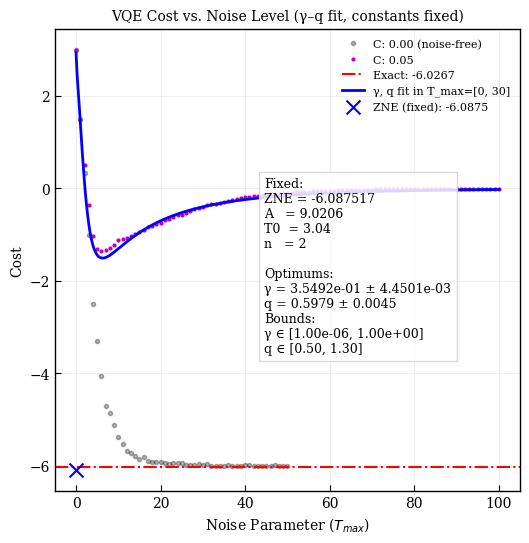

In [24]:
# --- Configuration & Parameters ---
mask_idx = 31

# Fixed constants (naming preserved)
n_exponent = BEST_n_FROM_C0

# Initial guesses and bounds [gamma, q]
p0 = [
    GAMMA_FROM_LARGE_T,  # reuse previous gamma estimate
    0.8
]

bounds = (
    [1e-6, 0.5],   # Lower bounds [gamma, q]
    [1.0,  1.3],   # Upper bounds
)

# --- Data Extraction ---
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][:mask_idx]

# --- Execution: Gamma–q Fit (constants fixed) ---
result_gq = fit_fq_noisy_gamma_q_only(
    t=t_data,
    y=y_data,
    sigma=sigma_data,
    ZNE=ZNE_c0_best,
    A=BEST_A0_FROM_C0,
    T0=BEST_T0_FROM_C0,
    n=n_exponent,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

popt = result_gq["output"]["popt"]
pcov = result_gq["output"]["pcov"]

# Errors
perr = np.sqrt(np.diag(pcov))

# Unpack
gamma_fit, q_fit = popt
gamma_err, q_err = perr


# --- Print Summary ---
print(f"\nGamma–q Fit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)

params_names = ['gamma', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

# --- Visualization ---
def f_noisy_model_fixed(t, g, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (
        ZNE_c0_best + BEST_A0_FROM_C0 / (1.0 + (t / BEST_T0_FROM_C0) ** n)
    )

t_grid = np.linspace(min(noise_levels), max(noise_levels), 400)
y_fit = f_noisy_model_fixed(t_grid, gamma_fit, q_fit)

plt.figure(figsize=(6, 6))

# Data
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=0.3, label="C: 0.00 (noise-free)")
plt.plot(noise_levels, vqe_means, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"γ, q fit in T_max=[0, {mask_idx-1}]")
plt.scatter(
    0, ZNE_c0_best,
    color="blue", marker="x", s=100, zorder=5,
    label=f"ZNE (fixed): {ZNE_c0_best:.4f}"
)

# Annotation
optimum_val_str = (
    f"Fixed:\n"
    f"ZNE = {ZNE_c0_best:.6f}\n"
    f"A   = {BEST_A0_FROM_C0:.4f}\n"
    f"T0  = {BEST_T0_FROM_C0:.2f}\n"
    f"n   = {n_exponent}\n\n"
    f"Optimums:\n"
    f"γ = {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q = {q_fit:.4f} ± {q_err:.4f}\n"
    f"Bounds:\n"
    f"γ ∈ [{bounds[0][0]:.2e}, {bounds[1][0]:.2e}]\n"
    f"q ∈ [{bounds[0][1]:.2f}, {bounds[1][1]:.2f}]"
)

plt.text(
    0.45, 0.30, optimum_val_str,
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray')
)

plt.title("VQE Cost vs. Noise Level (γ–q fit, constants fixed)", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()



Gamma–q Fit Results (n=2), T_max=[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50]
 Param |      Initial |       Fitted |        Error | Rel. Error
---------------------------------------------------------------------------
 gamma |   7.3530e-02 |   3.2431e-01 |   3.5586e-03 | 1.10e-02
     q |   8.0000e-01 |   6.4042e-01 |   3.1323e-03 | 4.89e-03


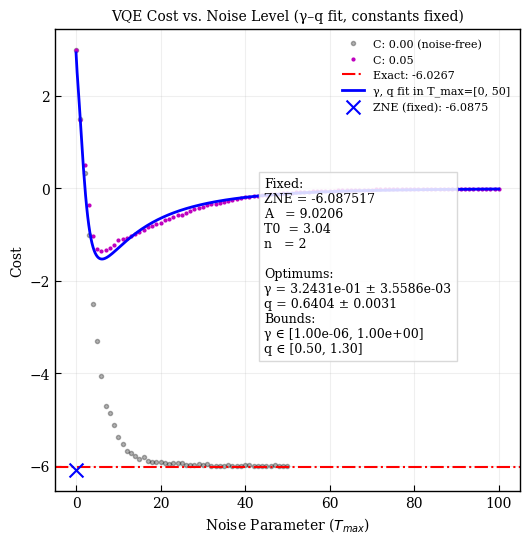

In [25]:
# --- Configuration & Parameters ---
mask_idx = 51

# Fixed constants (naming preserved)
n_exponent = BEST_n_FROM_C0

# Initial guesses and bounds [gamma, q]
p0 = [
    GAMMA_FROM_LARGE_T,  # reuse previous gamma estimate
    0.8
]

bounds = (
    [1e-6, 0.5],   # Lower bounds [gamma, q]
    [1.0,  1.3],   # Upper bounds
)

# --- Data Extraction ---
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][:mask_idx]

# --- Execution: Gamma–q Fit (constants fixed) ---
result_gq = fit_fq_noisy_gamma_q_only(
    t=t_data,
    y=y_data,
    sigma=sigma_data,
    ZNE=ZNE_c0_best,
    A=BEST_A0_FROM_C0,
    T0=BEST_T0_FROM_C0,
    n=n_exponent,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

popt = result_gq["output"]["popt"]
pcov = result_gq["output"]["pcov"]

# Errors
perr = np.sqrt(np.diag(pcov))

# Unpack
gamma_fit, q_fit = popt
gamma_err, q_err = perr

# --- Print Summary ---
print(f"\nGamma–q Fit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)

params_names = ['gamma', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

# --- Visualization ---
def f_noisy_model_fixed(t, g, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (
        ZNE_c0_best + BEST_A0_FROM_C0 / (1.0 + (t / BEST_T0_FROM_C0) ** n)
    )

t_grid = np.linspace(min(noise_levels), max(noise_levels), 400)
y_fit = f_noisy_model_fixed(t_grid, gamma_fit, q_fit)

plt.figure(figsize=(6, 6))

# Data
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=0.3, label="C: 0.00 (noise-free)")
plt.plot(noise_levels, vqe_means, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"γ, q fit in T_max=[0, {mask_idx-1}]")
plt.scatter(
    0, ZNE_c0_best,
    color="blue", marker="x", s=100, zorder=5,
    label=f"ZNE (fixed): {ZNE_c0_best:.4f}"
)

# Annotation
optimum_val_str = (
    f"Fixed:\n"
    f"ZNE = {ZNE_c0_best:.6f}\n"
    f"A   = {BEST_A0_FROM_C0:.4f}\n"
    f"T0  = {BEST_T0_FROM_C0:.2f}\n"
    f"n   = {n_exponent}\n\n"
    f"Optimums:\n"
    f"γ = {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q = {q_fit:.4f} ± {q_err:.4f}\n"
    f"Bounds:\n"
    f"γ ∈ [{bounds[0][0]:.2e}, {bounds[1][0]:.2e}]\n"
    f"q ∈ [{bounds[0][1]:.2f}, {bounds[1][1]:.2f}]"
)

plt.text(
    0.45, 0.30, optimum_val_str,
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray')
)

plt.title("VQE Cost vs. Noise Level (γ–q fit, constants fixed)", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()



Gamma–q Fit Results (n=2), T_max=[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100]
 Param |      Initial |       Fitted |        Error | Rel. Error
---------------------------------------------------------------------------
 gamma |   7.3530e-02 |   2.1579e-01 |   1.8554e-03 | 8.60e-03
     q |   8.0000e-01 |   7.6582e-01 |   2.0384e-03 | 2.66e-03


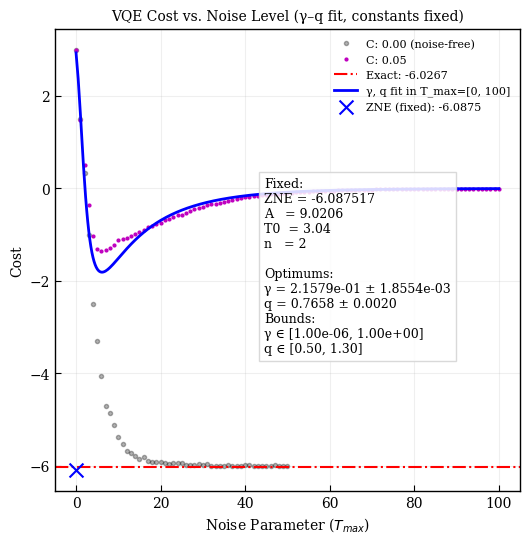

In [26]:
# --- Configuration & Parameters ---
mask_idx = 101

# Fixed constants (naming preserved)
n_exponent = BEST_n_FROM_C0

# Initial guesses and bounds [gamma, q]
p0 = [
    GAMMA_FROM_LARGE_T,  # reuse previous gamma estimate
    0.8
]

bounds = (
    [1e-6, 0.5],   # Lower bounds [gamma, q]
    [1.0,  1.3],   # Upper bounds
)

# --- Data Extraction ---
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][:mask_idx]

# --- Execution: Gamma–q Fit (constants fixed) ---
result_gq = fit_fq_noisy_gamma_q_only(
    t=t_data,
    y=y_data,
    sigma=sigma_data,
    ZNE=ZNE_c0_best,
    A=BEST_A0_FROM_C0,
    T0=BEST_T0_FROM_C0,
    n=n_exponent,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

popt = result_gq["output"]["popt"]
pcov = result_gq["output"]["pcov"]

# Errors
perr = np.sqrt(np.diag(pcov))

# Unpack
gamma_fit, q_fit = popt
gamma_err, q_err = perr

# --- Print Summary ---
print(f"\nGamma–q Fit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)

params_names = ['gamma', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

# --- Visualization ---
def f_noisy_model_fixed(t, g, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (
        ZNE_c0_best + BEST_A0_FROM_C0 / (1.0 + (t / BEST_T0_FROM_C0) ** n)
    )

t_grid = np.linspace(min(noise_levels), max(noise_levels), 400)
y_fit = f_noisy_model_fixed(t_grid, gamma_fit, q_fit)

plt.figure(figsize=(6, 6))

# Data
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=0.3, label="C: 0.00 (noise-free)")
plt.plot(noise_levels, vqe_means, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"γ, q fit in T_max=[0, {mask_idx-1}]")
plt.scatter(
    0, ZNE_c0_best,
    color="blue", marker="x", s=100, zorder=5,
    label=f"ZNE (fixed): {ZNE_c0_best:.4f}"
)

# Annotation
optimum_val_str = (
    f"Fixed:\n"
    f"ZNE = {ZNE_c0_best:.6f}\n"
    f"A   = {BEST_A0_FROM_C0:.4f}\n"
    f"T0  = {BEST_T0_FROM_C0:.2f}\n"
    f"n   = {n_exponent}\n\n"
    f"Optimums:\n"
    f"γ = {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q = {q_fit:.4f} ± {q_err:.4f}\n"
    f"Bounds:\n"
    f"γ ∈ [{bounds[0][0]:.2e}, {bounds[1][0]:.2e}]\n"
    f"q ∈ [{bounds[0][1]:.2f}, {bounds[1][1]:.2f}]"
)

plt.text(
    0.45, 0.30, optimum_val_str,
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray')
)

plt.title("VQE Cost vs. Noise Level (γ–q fit, constants fixed)", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()


---


Gamma–q Fit Results (n=2), T_max=[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30]
 Param |      Initial |       Fitted |        Error | Rel. Error
---------------------------------------------------------------------------
 gamma |   7.3530e-02 |   3.5492e-01 |   4.4501e-03 | 1.25e-02
     q |   8.0000e-01 |   5.9793e-01 |   4.4926e-03 | 7.51e-03

Reduced chi-square = 49146879531.4184 (dof = 29)


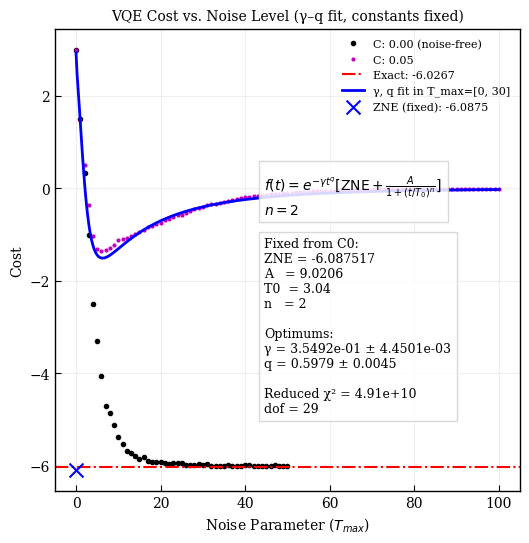

In [27]:
# --- Configuration & Parameters ---
mask_idx = 31

# Fixed constants (naming preserved)
n_exponent = BEST_n_FROM_C0

# Initial guesses and bounds [gamma, q]
p0 = [
    GAMMA_FROM_LARGE_T,  # reuse previous gamma estimate
    0.8
]

bounds = (
    [1e-6, 0.5],   # Lower bounds [gamma, q]
    [1.0,  1.3],   # Upper bounds
)

# --- Data Extraction ---
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][:mask_idx]

# --- Execution: Gamma–q Fit (constants fixed) ---
result_gq = fit_fq_noisy_gamma_q_only(
    t=t_data,
    y=y_data,
    sigma=sigma_data,
    ZNE=ZNE_c0_best,
    A=BEST_A0_FROM_C0,
    T0=BEST_T0_FROM_C0,
    n=n_exponent,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

popt = result_gq["output"]["popt"]
pcov = result_gq["output"]["pcov"]

# Errors
perr = np.sqrt(np.diag(pcov))

# Unpack
gamma_fit, q_fit = popt
gamma_err, q_err = perr

# --- Reduced Chi-square calculation ---
def f_noisy_model_fixed(t, g, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (
        ZNE_c0_best + BEST_A0_FROM_C0 / (1.0 + (t / BEST_T0_FROM_C0) ** n)
    )

y_model_data = f_noisy_model_fixed(t_data, gamma_fit, q_fit)

chi2 = np.sum(((y_data - y_model_data) / sigma_data) ** 2)
N = len(t_data)
p = 2  # gamma, q
dof = N - p
chi2_red = chi2 / dof

# --- Print Summary ---
print(f"\nGamma–q Fit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)

params_names = ['gamma', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

print(f"\nReduced chi-square = {chi2_red:.4f} (dof = {dof})")

# --- Visualization ---
t_grid = np.linspace(min(noise_levels), max(noise_levels), 400)
y_fit = f_noisy_model_fixed(t_grid, gamma_fit, q_fit)

plt.figure(figsize=(6, 6))

# Data
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=1, label="C: 0.00 (noise-free)")
plt.plot(noise_levels, vqe_means, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"γ, q fit in T_max=[0, {mask_idx-1}]")
plt.scatter(
    0, ZNE_c0_best,
    color="blue", marker="x", s=100, zorder=5,
    label=f"ZNE (fixed): {ZNE_c0_best:.4f}"
)

# Annotation (now includes reduced chi-square)
optimum_val_str = (
    f"Fixed from C0:\n"
    f"ZNE = {ZNE_c0_best:.6f}\n"
    f"A   = {BEST_A0_FROM_C0:.4f}\n"
    f"T0  = {BEST_T0_FROM_C0:.2f}\n"
    f"n   = {n_exponent}\n\n"
    f"Optimums:\n"
    f"γ = {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q = {q_fit:.4f} ± {q_err:.4f}\n\n"
    f"Reduced χ² = {chi2_red:.2e}\n"
    f"dof = {dof}"
)

plt.text(0.45, 0.60, F_NOISY_EQ, transform=plt.gca().transAxes, fontsize=10, 
         bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray'))
plt.text(
    0.45, 0.17,
    optimum_val_str,
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray')
)

plt.title("VQE Cost vs. Noise Level (γ–q fit, constants fixed)", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()



Gamma–q Fit Results (n=2), T_max=[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50]
 Param |      Initial |       Fitted |        Error | Rel. Error
---------------------------------------------------------------------------
 gamma |   7.3530e-02 |   3.2431e-01 |   3.5586e-03 | 1.10e-02
     q |   8.0000e-01 |   6.4042e-01 |   3.1323e-03 | 4.89e-03

Reduced chi-square = 29086928706.6717 (dof = 49)


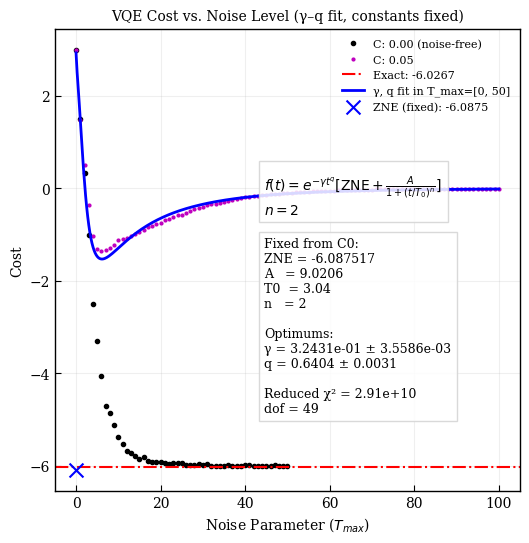

In [28]:
# --- Configuration & Parameters ---
mask_idx = 51

# Fixed constants (naming preserved)
n_exponent = BEST_n_FROM_C0

# Initial guesses and bounds [gamma, q]
p0 = [
    GAMMA_FROM_LARGE_T,  # reuse previous gamma estimate
    0.8
]

bounds = (
    [1e-6, 0.5],   # Lower bounds [gamma, q]
    [1.0,  1.3],   # Upper bounds
)

# --- Data Extraction ---
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][:mask_idx]

# --- Execution: Gamma–q Fit (constants fixed) ---
result_gq = fit_fq_noisy_gamma_q_only(
    t=t_data,
    y=y_data,
    sigma=sigma_data,
    ZNE=ZNE_c0_best,
    A=BEST_A0_FROM_C0,
    T0=BEST_T0_FROM_C0,
    n=n_exponent,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

popt = result_gq["output"]["popt"]
pcov = result_gq["output"]["pcov"]

# Errors
perr = np.sqrt(np.diag(pcov))

# Unpack
gamma_fit, q_fit = popt
gamma_err, q_err = perr

# --- Reduced Chi-square calculation ---
def f_noisy_model_fixed(t, g, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (
        ZNE_c0_best + BEST_A0_FROM_C0 / (1.0 + (t / BEST_T0_FROM_C0) ** n)
    )

y_model_data = f_noisy_model_fixed(t_data, gamma_fit, q_fit)

chi2 = np.sum(((y_data - y_model_data) / sigma_data) ** 2)
N = len(t_data)
p = 2  # gamma, q
dof = N - p
chi2_red = chi2 / dof

# --- Print Summary ---
print(f"\nGamma–q Fit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)

params_names = ['gamma', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

print(f"\nReduced chi-square = {chi2_red:.4f} (dof = {dof})")

# --- Visualization ---
t_grid = np.linspace(min(noise_levels), max(noise_levels), 400)
y_fit = f_noisy_model_fixed(t_grid, gamma_fit, q_fit)

plt.figure(figsize=(6, 6))

# Data
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=1, label="C: 0.00 (noise-free)")
plt.plot(noise_levels, vqe_means, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"γ, q fit in T_max=[0, {mask_idx-1}]")
plt.scatter(
    0, ZNE_c0_best,
    color="blue", marker="x", s=100, zorder=5,
    label=f"ZNE (fixed): {ZNE_c0_best:.4f}"
)

# Annotation (now includes reduced chi-square)
optimum_val_str = (
    f"Fixed from C0:\n"
    f"ZNE = {ZNE_c0_best:.6f}\n"
    f"A   = {BEST_A0_FROM_C0:.4f}\n"
    f"T0  = {BEST_T0_FROM_C0:.2f}\n"
    f"n   = {n_exponent}\n\n"
    f"Optimums:\n"
    f"γ = {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q = {q_fit:.4f} ± {q_err:.4f}\n\n"
    f"Reduced χ² = {chi2_red:.2e}\n"
    f"dof = {dof}"
)

plt.text(0.45, 0.60, F_NOISY_EQ, transform=plt.gca().transAxes, fontsize=10, 
         bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray'))
plt.text(
    0.45, 0.17,
    optimum_val_str,
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray')
)
plt.title("VQE Cost vs. Noise Level (γ–q fit, constants fixed)", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()



Gamma–q Fit Results (n=2), T_max=[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100]
 Param |      Initial |       Fitted |        Error | Rel. Error
---------------------------------------------------------------------------
 gamma |   7.3530e-02 |   2.1579e-01 |   1.8554e-03 | 8.60e-03
     q |   8.0000e-01 |   7.6582e-01 |   2.0384e-03 | 2.66e-03

Reduced chi-square = 14396560699.2968 (dof = 99)


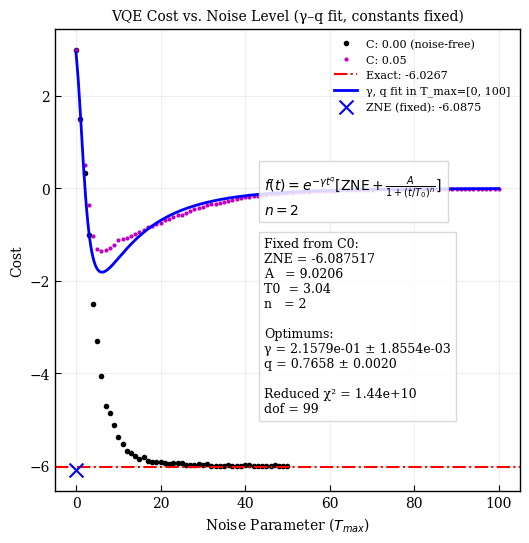

In [29]:
# --- Configuration & Parameters ---
mask_idx = 101

# Fixed constants (naming preserved)
n_exponent = BEST_n_FROM_C0

# Initial guesses and bounds [gamma, q]
p0 = [
    GAMMA_FROM_LARGE_T,  # reuse previous gamma estimate
    0.8
]

bounds = (
    [1e-6, 0.5],   # Lower bounds [gamma, q]
    [1.0,  1.3],   # Upper bounds
)

# --- Data Extraction ---
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][:mask_idx]

# --- Execution: Gamma–q Fit (constants fixed) ---
result_gq = fit_fq_noisy_gamma_q_only(
    t=t_data,
    y=y_data,
    sigma=sigma_data,
    ZNE=ZNE_c0_best,
    A=BEST_A0_FROM_C0,
    T0=BEST_T0_FROM_C0,
    n=n_exponent,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

popt = result_gq["output"]["popt"]
pcov = result_gq["output"]["pcov"]

# Errors
perr = np.sqrt(np.diag(pcov))

# Unpack
gamma_fit, q_fit = popt
gamma_err, q_err = perr

# --- Reduced Chi-square calculation ---
def f_noisy_model_fixed(t, g, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (
        ZNE_c0_best + BEST_A0_FROM_C0 / (1.0 + (t / BEST_T0_FROM_C0) ** n)
    )

y_model_data = f_noisy_model_fixed(t_data, gamma_fit, q_fit)

chi2 = np.sum(((y_data - y_model_data) / sigma_data) ** 2)
N = len(t_data)
p = 2  # gamma, q
dof = N - p
chi2_red = chi2 / dof

# --- Print Summary ---
print(f"\nGamma–q Fit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)

params_names = ['gamma', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

print(f"\nReduced chi-square = {chi2_red:.4f} (dof = {dof})")

# --- Visualization ---
t_grid = np.linspace(min(noise_levels), max(noise_levels), 400)
y_fit = f_noisy_model_fixed(t_grid, gamma_fit, q_fit)

plt.figure(figsize=(6, 6))

# Data
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=1, label="C: 0.00 (noise-free)")
plt.plot(noise_levels, vqe_means, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"γ, q fit in T_max=[0, {mask_idx-1}]")
plt.scatter(
    0, ZNE_c0_best,
    color="blue", marker="x", s=100, zorder=5,
    label=f"ZNE (fixed): {ZNE_c0_best:.4f}"
)

# Annotation (now includes reduced chi-square)
optimum_val_str = (
    f"Fixed from C0:\n"
    f"ZNE = {ZNE_c0_best:.6f}\n"
    f"A   = {BEST_A0_FROM_C0:.4f}\n"
    f"T0  = {BEST_T0_FROM_C0:.2f}\n"
    f"n   = {n_exponent}\n\n"
    f"Optimums:\n"
    f"γ = {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q = {q_fit:.4f} ± {q_err:.4f}\n\n"
    f"Reduced χ² = {chi2_red:.2e}\n"
    f"dof = {dof}"
)
plt.text(0.45, 0.60, F_NOISY_EQ, transform=plt.gca().transAxes, fontsize=10, 
         bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray'))
plt.text(
    0.45, 0.17,
    optimum_val_str,
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray')
)

plt.title("VQE Cost vs. Noise Level (γ–q fit, constants fixed)", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()


---

setting std = [1] and reduced xi


Gamma–q Fit Results (n=2), T_max=[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30]
 Param |      Initial |       Fitted |        Error | Rel. Error
---------------------------------------------------------------------------
 gamma |   7.3530e-02 |   4.6681e-01 |   2.8925e-01 | 6.20e-01
     q |   8.0000e-01 |   5.0616e-01 |   2.3152e-01 | 4.57e-01

Reduced chi-square = 0.0114 (dof = 29)


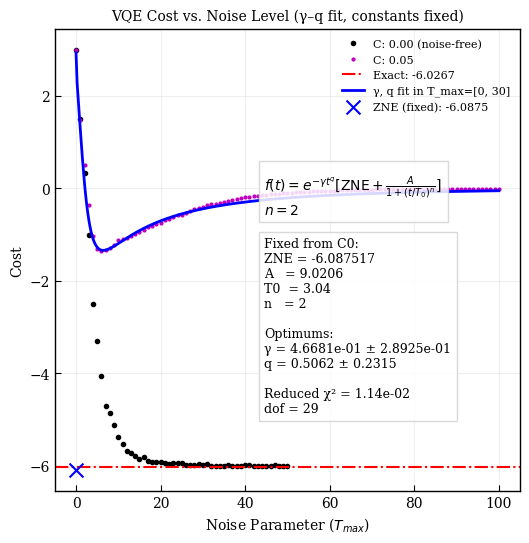

In [33]:
# --- Configuration & Parameters ---
mask_idx = 31

# Fixed constants (naming preserved)
n_exponent = BEST_n_FROM_C0

# Initial guesses and bounds [gamma, q]
p0 = [
    GAMMA_FROM_LARGE_T,  # reuse previous gamma estimate
    0.8
]

bounds = (
    [1e-6, 0.5],   # Lower bounds [gamma, q]
    [1.0,  1.3],   # Upper bounds
)

# --- Data Extraction ---
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = np.ones_like(y_data)

# --- Execution: Gamma–q Fit (constants fixed) ---
result_gq = fit_fq_noisy_gamma_q_only(
    t=t_data,
    y=y_data,
    sigma=sigma_data,
    ZNE=ZNE_c0_best,
    A=BEST_A0_FROM_C0,
    T0=BEST_T0_FROM_C0,
    n=n_exponent,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

popt = result_gq["output"]["popt"]
pcov = result_gq["output"]["pcov"]

# Errors
perr = np.sqrt(np.diag(pcov))

# Unpack
gamma_fit, q_fit = popt
gamma_err, q_err = perr

# --- Reduced Chi-square calculation ---
def f_noisy_model_fixed(t, g, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (
        ZNE_c0_best + BEST_A0_FROM_C0 / (1.0 + (t / BEST_T0_FROM_C0) ** n)
    )

y_model_data = f_noisy_model_fixed(t_data, gamma_fit, q_fit)

chi2 = np.sum(((y_data - y_model_data) / sigma_data) ** 2)
N = len(t_data)
p = 2  # gamma, q
dof = N - p
chi2_red = chi2 / dof

# --- Print Summary ---
print(f"\nGamma–q Fit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)

params_names = ['gamma', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

print(f"\nReduced chi-square = {chi2_red:.4f} (dof = {dof})")

# --- Visualization ---
t_grid = np.linspace(min(noise_levels), max(noise_levels), 400)
y_fit = f_noisy_model_fixed(t_grid, gamma_fit, q_fit)

plt.figure(figsize=(6, 6))

# Data
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=1, label="C: 0.00 (noise-free)")
plt.plot(noise_levels, vqe_means, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"γ, q fit in T_max=[0, {mask_idx-1}]")
plt.scatter(
    0, ZNE_c0_best,
    color="blue", marker="x", s=100, zorder=5,
    label=f"ZNE (fixed): {ZNE_c0_best:.4f}"
)

# Annotation (now includes reduced chi-square)
optimum_val_str = (
    f"Fixed from C0:\n"
    f"ZNE = {ZNE_c0_best:.6f}\n"
    f"A   = {BEST_A0_FROM_C0:.4f}\n"
    f"T0  = {BEST_T0_FROM_C0:.2f}\n"
    f"n   = {n_exponent}\n\n"
    f"Optimums:\n"
    f"γ = {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q = {q_fit:.4f} ± {q_err:.4f}\n\n"
    f"Reduced χ² = {chi2_red:.2e}\n"
    f"dof = {dof}"
)
plt.text(0.45, 0.60, F_NOISY_EQ, transform=plt.gca().transAxes, fontsize=10, 
         bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray'))
plt.text(
    0.45, 0.17,
    optimum_val_str,
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray')
)

plt.title("VQE Cost vs. Noise Level (γ–q fit, constants fixed)", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()



Gamma–q Fit Results (n=2), T_max=[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50]
 Param |      Initial |       Fitted |        Error | Rel. Error
---------------------------------------------------------------------------
 gamma |   7.3530e-02 |   4.2453e-01 |   2.2339e-01 | 5.26e-01
     q |   8.0000e-01 |   5.4683e-01 |   1.8411e-01 | 3.37e-01

Reduced chi-square = 0.0085 (dof = 49)


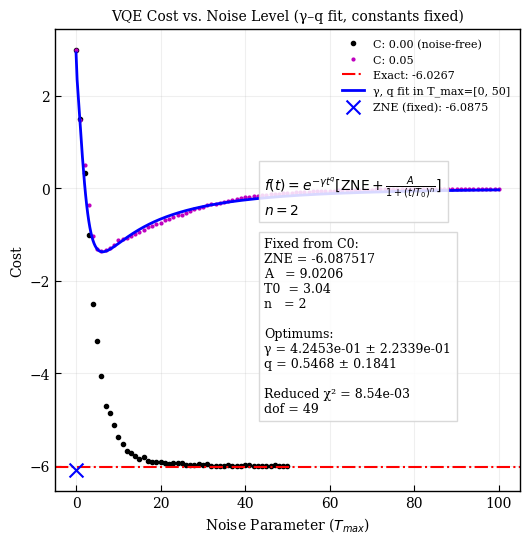

In [34]:
# --- Configuration & Parameters ---
mask_idx = 51

# Fixed constants (naming preserved)
n_exponent = BEST_n_FROM_C0

# Initial guesses and bounds [gamma, q]
p0 = [
    GAMMA_FROM_LARGE_T,  # reuse previous gamma estimate
    0.8
]

bounds = (
    [1e-6, 0.5],   # Lower bounds [gamma, q]
    [1.0,  1.3],   # Upper bounds
)

# --- Data Extraction ---
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = np.ones_like(y_data)

# --- Execution: Gamma–q Fit (constants fixed) ---
result_gq = fit_fq_noisy_gamma_q_only(
    t=t_data,
    y=y_data,
    sigma=sigma_data,
    ZNE=ZNE_c0_best,
    A=BEST_A0_FROM_C0,
    T0=BEST_T0_FROM_C0,
    n=n_exponent,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

popt = result_gq["output"]["popt"]
pcov = result_gq["output"]["pcov"]

# Errors
perr = np.sqrt(np.diag(pcov))

# Unpack
gamma_fit, q_fit = popt
gamma_err, q_err = perr

# --- Reduced Chi-square calculation ---
def f_noisy_model_fixed(t, g, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (
        ZNE_c0_best + BEST_A0_FROM_C0 / (1.0 + (t / BEST_T0_FROM_C0) ** n)
    )

y_model_data = f_noisy_model_fixed(t_data, gamma_fit, q_fit)

chi2 = np.sum(((y_data - y_model_data) / sigma_data) ** 2)
N = len(t_data)
p = 2  # gamma, q
dof = N - p
chi2_red = chi2 / dof

# --- Print Summary ---
print(f"\nGamma–q Fit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)

params_names = ['gamma', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

print(f"\nReduced chi-square = {chi2_red:.4f} (dof = {dof})")

# --- Visualization ---
t_grid = np.linspace(min(noise_levels), max(noise_levels), 400)
y_fit = f_noisy_model_fixed(t_grid, gamma_fit, q_fit)

plt.figure(figsize=(6, 6))

# Data
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=1, label="C: 0.00 (noise-free)")
plt.plot(noise_levels, vqe_means, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"γ, q fit in T_max=[0, {mask_idx-1}]")
plt.scatter(
    0, ZNE_c0_best,
    color="blue", marker="x", s=100, zorder=5,
    label=f"ZNE (fixed): {ZNE_c0_best:.4f}"
)

# Annotation (now includes reduced chi-square)
optimum_val_str = (
    f"Fixed from C0:\n"
    f"ZNE = {ZNE_c0_best:.6f}\n"
    f"A   = {BEST_A0_FROM_C0:.4f}\n"
    f"T0  = {BEST_T0_FROM_C0:.2f}\n"
    f"n   = {n_exponent}\n\n"
    f"Optimums:\n"
    f"γ = {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q = {q_fit:.4f} ± {q_err:.4f}\n\n"
    f"Reduced χ² = {chi2_red:.2e}\n"
    f"dof = {dof}"
)
plt.text(0.45, 0.60, F_NOISY_EQ, transform=plt.gca().transAxes, fontsize=10, 
         bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray'))
plt.text(
    0.45, 0.17,
    optimum_val_str,
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray')
)

plt.title("VQE Cost vs. Noise Level (γ–q fit, constants fixed)", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()



Gamma–q Fit Results (n=2), T_max=[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100]
 Param |      Initial |       Fitted |        Error | Rel. Error
---------------------------------------------------------------------------
 gamma |   7.3530e-02 |   3.9816e-01 |   1.9395e-01 | 4.87e-01
     q |   8.0000e-01 |   5.7266e-01 |   1.6636e-01 | 2.91e-01

Reduced chi-square = 0.0052 (dof = 99)


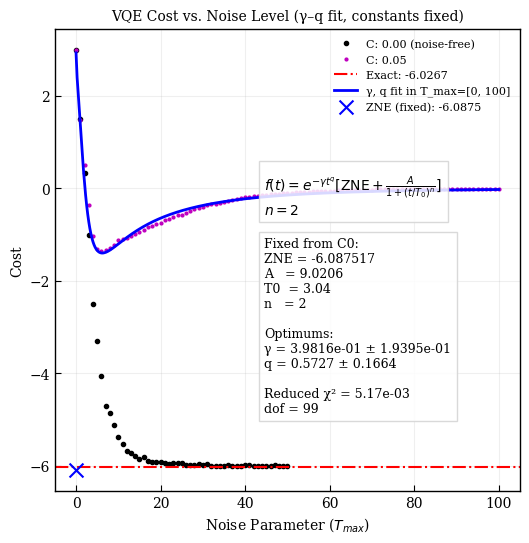

In [35]:
# --- Configuration & Parameters ---
mask_idx = 101

# Fixed constants (naming preserved)
n_exponent = BEST_n_FROM_C0

# Initial guesses and bounds [gamma, q]
p0 = [
    GAMMA_FROM_LARGE_T,  # reuse previous gamma estimate
    0.8
]

bounds = (
    [1e-6, 0.5],   # Lower bounds [gamma, q]
    [1.0,  1.3],   # Upper bounds
)

# --- Data Extraction ---
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = np.ones_like(y_data)

# --- Execution: Gamma–q Fit (constants fixed) ---
result_gq = fit_fq_noisy_gamma_q_only(
    t=t_data,
    y=y_data,
    sigma=sigma_data,
    ZNE=ZNE_c0_best,
    A=BEST_A0_FROM_C0,
    T0=BEST_T0_FROM_C0,
    n=n_exponent,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

popt = result_gq["output"]["popt"]
pcov = result_gq["output"]["pcov"]

# Errors
perr = np.sqrt(np.diag(pcov))

# Unpack
gamma_fit, q_fit = popt
gamma_err, q_err = perr

# --- Reduced Chi-square calculation ---
def f_noisy_model_fixed(t, g, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (
        ZNE_c0_best + BEST_A0_FROM_C0 / (1.0 + (t / BEST_T0_FROM_C0) ** n)
    )

y_model_data = f_noisy_model_fixed(t_data, gamma_fit, q_fit)

chi2 = np.sum(((y_data - y_model_data) / sigma_data) ** 2)
N = len(t_data)
p = 2  # gamma, q
dof = N - p
chi2_red = chi2 / dof

# --- Print Summary ---
print(f"\nGamma–q Fit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)

params_names = ['gamma', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

print(f"\nReduced chi-square = {chi2_red:.4f} (dof = {dof})")

# --- Visualization ---
t_grid = np.linspace(min(noise_levels), max(noise_levels), 400)
y_fit = f_noisy_model_fixed(t_grid, gamma_fit, q_fit)

plt.figure(figsize=(6, 6))

# Data
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=1, label="C: 0.00 (noise-free)")
plt.plot(noise_levels, vqe_means, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"γ, q fit in T_max=[0, {mask_idx-1}]")
plt.scatter(
    0, ZNE_c0_best,
    color="blue", marker="x", s=100, zorder=5,
    label=f"ZNE (fixed): {ZNE_c0_best:.4f}"
)

# Annotation (now includes reduced chi-square)
optimum_val_str = (
    f"Fixed from C0:\n"
    f"ZNE = {ZNE_c0_best:.6f}\n"
    f"A   = {BEST_A0_FROM_C0:.4f}\n"
    f"T0  = {BEST_T0_FROM_C0:.2f}\n"
    f"n   = {n_exponent}\n\n"
    f"Optimums:\n"
    f"γ = {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q = {q_fit:.4f} ± {q_err:.4f}\n\n"
    f"Reduced χ² = {chi2_red:.2e}\n"
    f"dof = {dof}"
)
plt.text(0.45, 0.60, F_NOISY_EQ, transform=plt.gca().transAxes, fontsize=10, 
         bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray'))
plt.text(
    0.45, 0.17,
    optimum_val_str,
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray')
)

plt.title("VQE Cost vs. Noise Level (γ–q fit, constants fixed)", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()
